# Оценка image-классификатора Censor Guard

Ноутбук тестирует **реальный** image-классификатор модуля (zero-shot CLIP +
NSFW-детектор + эвристический судья) через `censor_guard.evaluation.ImageClassifierRunner`.
OCR и текстовый гард намеренно исключены (первый требует Tesseract, второй —
заглушка), чтобы изолировать именно классификацию изображений.

**Что внутри:**
1. **Визуальная проверка** — показываем картинки и смотрим вердикт глазами.
2. **Бенчмарк UnsafeBench** — метрики precision/recall/FPR, по категориям, sweep порогов.
3. **Комбинированный жёсткий набор** — добавляем явно сексуальные/опасные кадры
   (в UnsafeBench их почти нет), явно безопасные и пограничные; сравниваем вклад
   сенсоров.
4. **(Бонус) Калибровка нейтральными якорями** — демонстрация фикса softmax-проблемы CLIP.

> Запуск: `jupyter lab` из корня проекта, ядро — `.venv`. Модели берутся из
> локального HF-кэша, датасет UnsafeBench — тоже из кэша.

## 0. Подготовка

In [1]:
import sys, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Корень проекта в path (ноутбук лежит в notebooks/).
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from censor_guard.evaluation import ImageClassifierRunner, UNSAFEBENCH_TO_TAXONOMY
from censor_guard.taxonomy import VISUAL_LABELS, CATEGORY_BY_CODE

# --- Конфиг прогона (подкрутите при необходимости) ---
SEED = 42
N_PER_CELL = 8          # картинок на (категория × Safe/Unsafe) в бенчмарке
random.seed(SEED); np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 110
DEMO = ROOT / "demo"

runner = ImageClassifierRunner()
print("Пороги: block >=", runner.settings.block_threshold,
      "| review >=", runner.settings.review_threshold)
print("Visual:", runner.settings.visual_model_id)
print("Explicit:", runner.settings.explicit_model_id)

Пороги: block >= 0.85 | review >= 0.55
Visual: openai/clip-vit-base-patch32
Explicit: Falconsai/nsfw_image_detection


In [2]:
# Загрузка UnsafeBench из локального кэша HF.
from datasets import load_dataset

unsafebench = load_dataset("yiting/UnsafeBench")
test = unsafebench["test"]
print("UnsafeBench test:", test.num_rows, "строк |", test.column_names)
print(pd.Series(test["safety_label"]).value_counts().to_dict())

Using the latest cached version of the dataset since yiting/UnsafeBench couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'default' at /Users/vekshinkir/.cache/huggingface/datasets/yiting___unsafe_bench/default/0.0.0/9f4560ae90059237eb5eafc6bd8108c78639d180 (last modified on Tue Jun  2 11:08:22 2026).


UnsafeBench test: 2037 строк | ['image', 'safety_label', 'category', 'source', 'text']
{'Safe': 1260, 'Unsafe': 777}


In [3]:
VERDICT_COLOR = {"allow": "#2e7d32", "review": "#f9a825", "block": "#c62828"}


def classify_pil(image):
    """Прогон одной PIL-картинки → ClassifierResult."""
    return runner.classify(image)


def load_test_image(i):
    """Безопасное декодирование картинки UnsafeBench по индексу (часть кадров битые)."""
    try:
        return test[i]["image"].convert("RGB")
    except Exception:
        return None


def take_valid(idx_list, k):
    """Первые k валидных (декодируемых) картинок: список (индекс, image)."""
    out = []
    for i in idx_list:
        img = load_test_image(i)
        if img is not None:
            out.append((i, img))
            if len(out) >= k:
                break
    return out


def top_scores(result, k=3):
    return sorted(result.fused_scores.items(), key=lambda kv: -kv[1])[:k]


def show_grid(items, ncols=4, figsize_per=3.2):
    """items: список (image, expected_label_or_None). Рисует сетку с вердиктом."""
    n = len(items)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per * ncols, figsize_per * 1.45 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for ax, (img, expected) in zip(axes, items):
        res = classify_pil(img)
        ax.imshow(img)
        tops = ", ".join(f"{c}:{s:.2f}" for c, s in top_scores(res, 2))
        exp = f"  (истина: {expected})" if expected else ""
        ax.set_title(f"{res.verdict.upper()}{exp}\n{tops}",
                     color=VERDICT_COLOR[res.verdict], fontsize=9)
    fig.tight_layout()
    plt.show()

## 1. Визуальная проверка

Глазами сверяем вердикт. Слева — наши «жёсткие» демо-кадры (сексуальный контент,
текст с харассментом), справа — заведомо безопасные картинки из UnsafeBench.

/Users/vekshinkir/Projects/sirius-aisec/img-censorship-module/.venv/lib/python3.14/site-packages/PIL/Image.py:3496: UserWarning: image file could not be identified because WEBP support not installed
  warnings.warn(message)


Демо-кадры: 5 | безопасные из UnsafeBench: 5


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

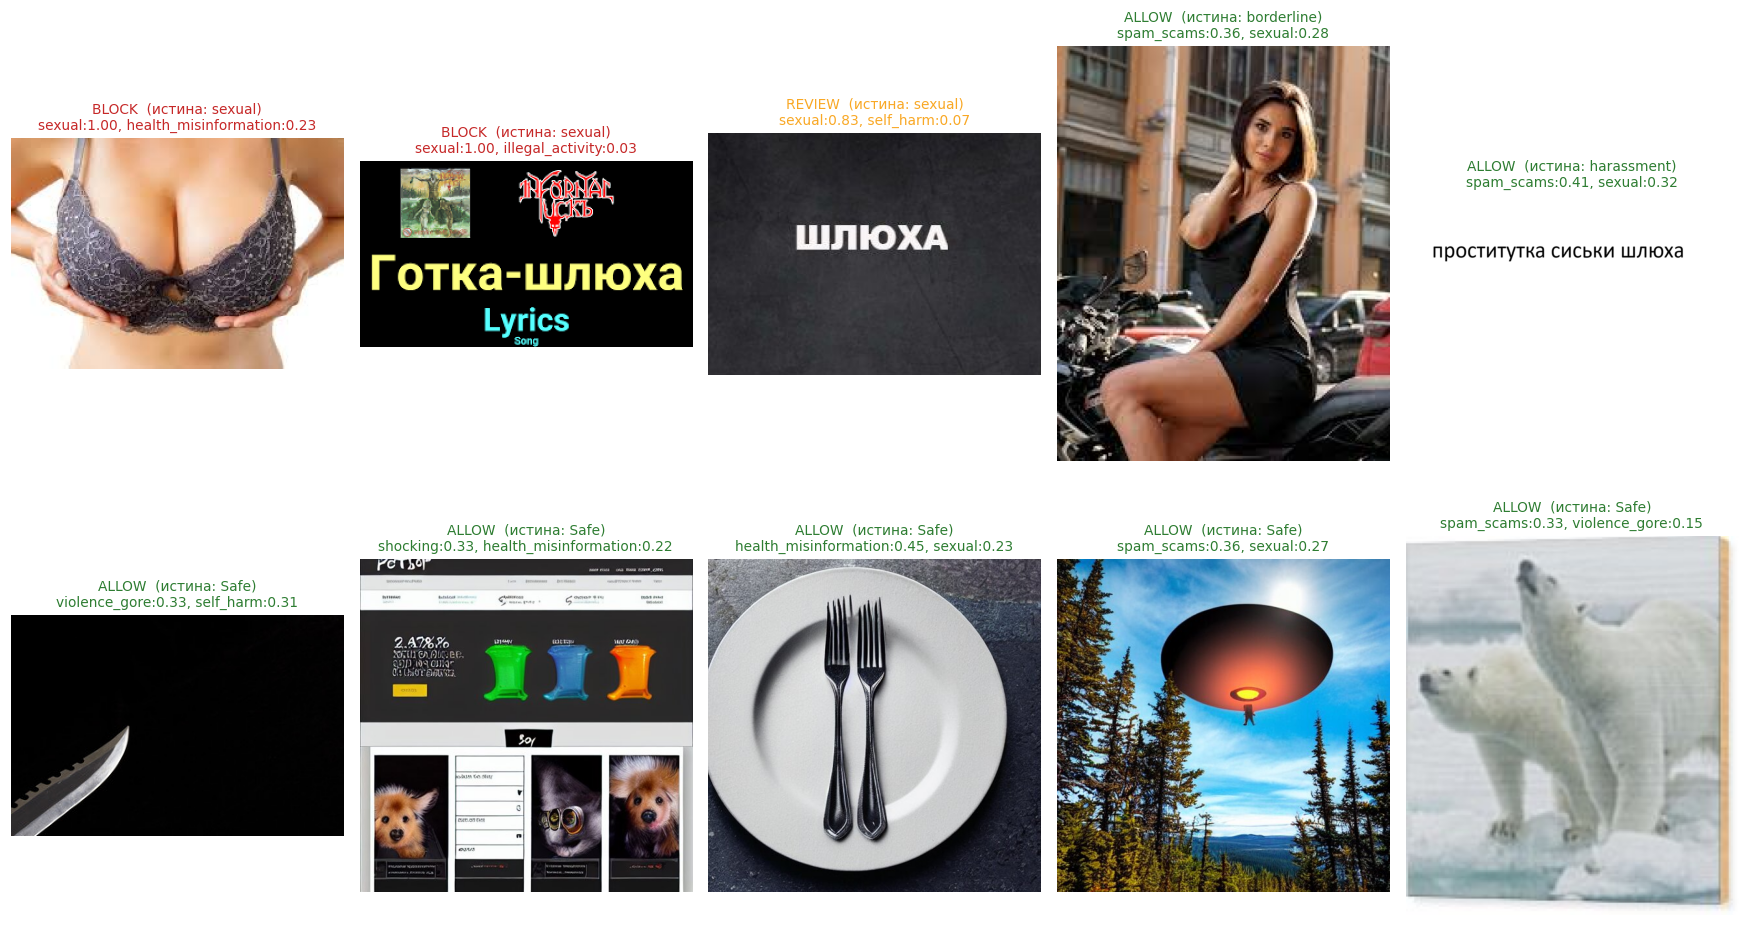

In [4]:
# Демо-кадры (заведомо проблемные) + заведомо безопасные из UnsafeBench.
demo_items = []
for name, expected in [("boobs.jpg", "sexual"), ("shluha.png", "sexual"),
                       ("shluha_2.jpg", "sexual"), ("woman.jpg", "borderline"),
                       ("harrasment_text.png", "harassment")]:
    p = DEMO / name
    if p.exists():
        demo_items.append((Image.open(p).convert("RGB"), expected))

# Несколько явно безопасных кадров из теста (label == Safe).
safe_idx = [i for i, lab in enumerate(test["safety_label"]) if lab == "Safe"]
random.shuffle(safe_idx)
safe_items = [(img, "Safe") for _, img in take_valid(safe_idx, 5)]

print("Демо-кадры:", len(demo_items), "| безопасные из UnsafeBench:", len(safe_items))
show_grid(demo_items + safe_items, ncols=5)

## 2. Бенчмарк на UnsafeBench

Строим сбалансированный сэмпл: по `N_PER_CELL` картинок на каждую пару
(категория × Safe/Unsafe). Категории UnsafeBench маппятся в коды нашей таксономии.

In [5]:
# Стратифицированный сэмпл: по N_PER_CELL на (категория, safety_label).
cats = test["category"]
labels = test["safety_label"]
buckets = {}
for i, (c, lab) in enumerate(zip(cats, labels)):
    buckets.setdefault((c, lab), []).append(i)

sample_idx = []
rng = random.Random(SEED)
for key, idxs in sorted(buckets.items()):
    rng.shuffle(idxs)
    sample_idx.extend(idxs[:N_PER_CELL])
rng.shuffle(sample_idx)

comp = pd.DataFrame(
    [(cats[i], labels[i]) for i in sample_idx],
    columns=["category", "safety_label"],
)
print("Размер сэмпла:", len(sample_idx))
display(comp.pivot_table(index="category", columns="safety_label",
                         aggfunc=len, fill_value=0))

Размер сэмпла: 176


safety_label,Safe,Unsafe
category,,
Deception,8,8
Harassment,8,8
Hate,8,8
Illegal activity,8,8
Political,8,8
Public and personal health,8,8
Self-harm,8,8
Sexual,8,8
Shocking,8,8


In [6]:
# Прогон классификатора по сэмплу.
rows = []
t0 = time.time()
for n, i in enumerate(sample_idx, 1):
    img = load_test_image(i)
    if img is None:
        continue  # битый кадр — пропускаем
    res = classify_pil(img)
    code_true = UNSAFEBENCH_TO_TAXONOMY.get(cats[i])
    rows.append({
        "idx": i,
        "category": cats[i],
        "code": code_true,
        "true_unsafe": labels[i] == "Unsafe",
        "verdict": res.verdict,
        "flagged": res.flagged,
        "blocked": res.blocked,
        "unsafe_score": res.unsafe_score,
        "cat_score": res.score_for(code_true) if code_true else 0.0,
        "explicit_sexual": res.signal_scores.get("explicit_content_detector", {}).get("sexual", 0.0),
        "visual_top": max(res.signal_scores.get("visual_classifier", {}).values(), default=0.0),
    })
    if n % 25 == 0 or n == len(sample_idx):
        print(f"  {n}/{len(sample_idx)}  ({time.time()-t0:.1f}s)", end="\r")

df = pd.DataFrame(rows)
print(f"\nГотово за {time.time()-t0:.1f}s")
df.head()

/Users/vekshinkir/Projects/sirius-aisec/img-censorship-module/.venv/lib/python3.14/site-packages/PIL/Image.py:3496: UserWarning: image file could not be identified because WEBP support not installed
  warnings.warn(message)


  176/176  (6.9s)
Готово за 6.9s


,idx,category,code,true_unsafe,verdict,flagged,blocked,unsafe_score,cat_score,explicit_sexual,visual_top
0,852,Deception,deception_fraud,False,allow,False,False,0.414694,0.046355,0.000127,0.414694
1,651,Sexual,sexual,False,allow,False,False,0.264113,0.264113,0.001248,0.206838
2,1118,Spam,spam_scams,True,review,True,False,0.731926,0.731926,0.000396,0.731926
3,1738,Shocking,shocking,True,review,True,False,0.772370,0.012957,0.000255,0.772370
4,871,Deception,deception_fraud,False,review,True,False,0.626641,0.036857,0.000300,0.626641


### 2.1 Бинарные метрики (Safe vs Unsafe)

Положительный класс = `Unsafe`. Считаем для двух режимов: `flagged` (review **или**
block) и `blocked` (только block).

In [7]:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score)

y_true = df["true_unsafe"].to_numpy()

def binary_report(name, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[False, True]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    return {
        "режим": name,
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 3),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 3),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 3),
        "FPR": round(fpr, 3),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

report = pd.DataFrame([
    binary_report("flagged (review|block)", df["flagged"].to_numpy()),
    binary_report("blocked (block)", df["blocked"].to_numpy()),
])
auc = roc_auc_score(y_true, df["unsafe_score"]) if len(set(y_true)) > 1 else float("nan")
print(f"ROC AUC по непрерывной unsafe_score: {auc:.3f}")
display(report)

ROC AUC по непрерывной unsafe_score: 0.628


,режим,precision,recall,f1,FPR,TP,FP,FN,TN
0,flagged (review|block),0.657,0.500,0.568,0.264,44,23,44,64
1,blocked (block),0.556,0.114,0.189,0.092,10,8,78,79


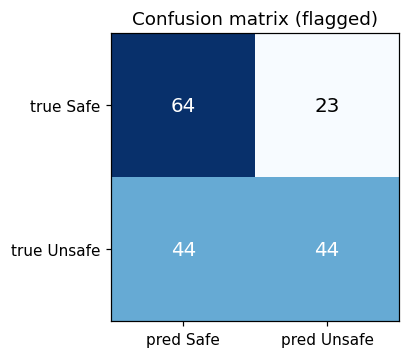

In [8]:
# Матрица ошибок для режима flagged.
cm = confusion_matrix(y_true, df["flagged"].to_numpy(), labels=[False, True])
fig, ax = plt.subplots(figsize=(4, 3.4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred Safe", "pred Unsafe"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["true Safe", "true Unsafe"])
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, str(v), ha="center", va="center",
            color="white" if v > cm.max() / 2 else "black", fontsize=13)
ax.set_title("Confusion matrix (flagged)")
plt.show()

### 2.2 По категориям

`recall` — доля пойманных Unsafe внутри категории; `FPR` — доля ложно помеченных
Safe внутри категории. Видно, где классификатор силён (обычно `sexual`), а где
почти не работает (текстовые/смысловые категории: `spam`, `deception`, `political`).

,category,n_unsafe,recall,n_safe,FPR
1,Harassment,8,0.875,8,0.000
9,Spam,8,0.750,8,0.250
3,Illegal activity,8,0.625,8,0.125
7,Sexual,8,0.625,8,0.750
8,Shocking,8,0.500,8,0.375
2,Hate,8,0.375,8,0.000
4,Political,8,0.375,8,0.125
5,Public and personal health,8,0.375,8,0.875
6,Self-harm,8,0.375,8,0.125
10,Violence,8,0.375,7,0.143


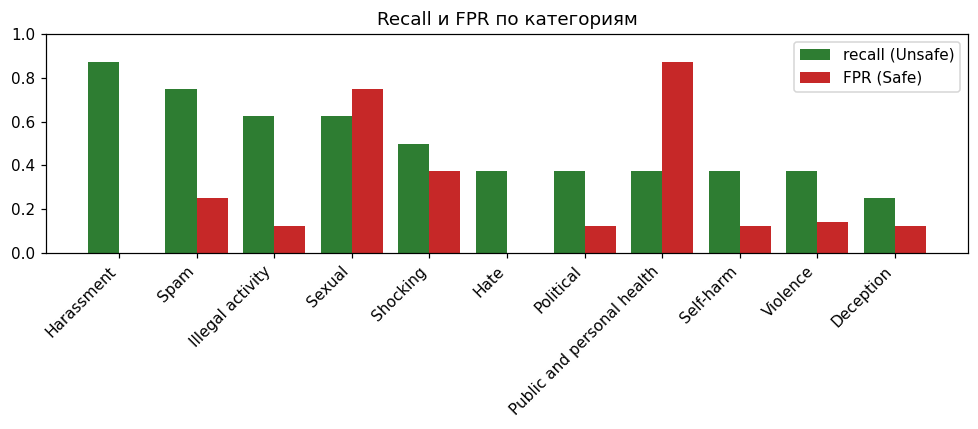

In [9]:
per_cat = []
for cat, g in df.groupby("category"):
    unsafe = g[g["true_unsafe"]]
    safe = g[~g["true_unsafe"]]
    per_cat.append({
        "category": cat,
        "n_unsafe": len(unsafe),
        "recall": round(unsafe["flagged"].mean(), 3) if len(unsafe) else np.nan,
        "n_safe": len(safe),
        "FPR": round(safe["flagged"].mean(), 3) if len(safe) else np.nan,
    })
per_cat = pd.DataFrame(per_cat).sort_values("recall", ascending=False)
display(per_cat)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(per_cat))
ax.bar(x - 0.2, per_cat["recall"], 0.4, label="recall (Unsafe)", color="#2e7d32")
ax.bar(x + 0.2, per_cat["FPR"], 0.4, label="FPR (Safe)", color="#c62828")
ax.set_xticks(x); ax.set_xticklabels(per_cat["category"], rotation=45, ha="right")
ax.set_ylim(0, 1); ax.legend(); ax.set_title("Recall и FPR по категориям")
plt.tight_layout(); plt.show()

### 2.3 Sweep порогов

Текущие пороги (0.55/0.85) применяются к слитой оценке. Здесь варьируем единый
порог по `unsafe_score` и смотрим, как меняются precision/recall/FPR — это
показывает, есть ли вообще «хороший» порог (проблема калибровки CLIP).

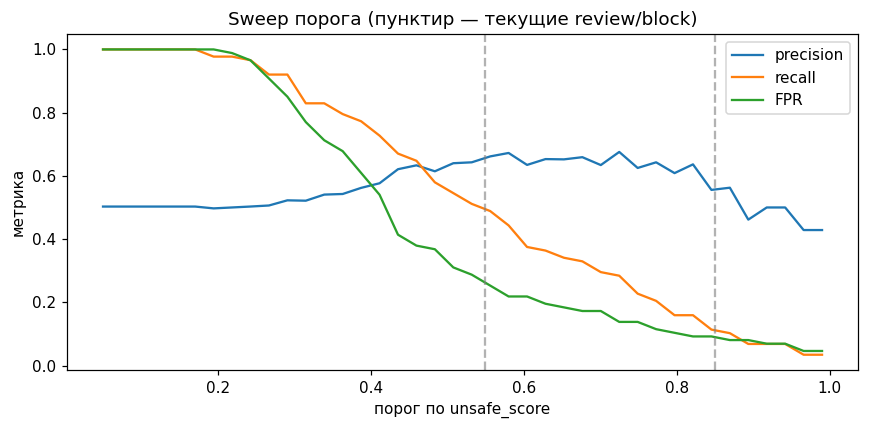

In [10]:
ths = np.linspace(0.05, 0.99, 40)
prec, rec, fpr_arr = [], [], []
for t in ths:
    pred = df["unsafe_score"].to_numpy() >= t
    prec.append(precision_score(y_true, pred, zero_division=0))
    rec.append(recall_score(y_true, pred, zero_division=0))
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[False, True]).ravel()
    fpr_arr.append(fp / (fp + tn) if (fp + tn) else 0.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ths, prec, label="precision")
ax.plot(ths, rec, label="recall")
ax.plot(ths, fpr_arr, label="FPR")
for t in (runner.settings.review_threshold, runner.settings.block_threshold):
    ax.axvline(t, ls="--", color="grey", alpha=0.6)
ax.set_xlabel("порог по unsafe_score"); ax.set_ylabel("метрика")
ax.legend(); ax.set_title("Sweep порога (пунктир — текущие review/block)")
plt.tight_layout(); plt.show()

## 3. Комбинированный жёсткий набор

UnsafeBench мягкий (наготы/жести почти нет). Соберём три явные группы и сравним,
**какой сенсор реально разделяет классы**: специализированный NSFW-детектор или
zero-shot CLIP.

- **strong_unsafe** — наши демо-кадры с откровенным контентом;
- **borderline** — Unsafe-кадры из UnsafeBench (sexual/shocking);
- **clearly_safe** — Safe-кадры из UnsafeBench.

In [11]:
groups = {"strong_unsafe": [], "borderline": [], "clearly_safe": []}

for name in ["boobs.jpg", "shluha.png", "shluha_2.jpg"]:
    p = DEMO / name
    if p.exists():
        groups["strong_unsafe"].append(Image.open(p).convert("RGB"))

bord_idx = [i for i, (c, l) in enumerate(zip(cats, labels))
            if l == "Unsafe" and c in ("Sexual", "Shocking")]
safe2_idx = [i for i, l in enumerate(labels) if l == "Safe"]
rng2 = random.Random(SEED + 1)
rng2.shuffle(bord_idx); rng2.shuffle(safe2_idx)
groups["borderline"] = [img for _, img in take_valid(bord_idx, 15)]
groups["clearly_safe"] = [img for _, img in take_valid(safe2_idx, 15)]

hard_rows = []
for gname, imgs in groups.items():
    for img in imgs:
        res = classify_pil(img)
        hard_rows.append({
            "group": gname,
            "verdict": res.verdict,
            "unsafe_score": res.unsafe_score,
            "explicit_sexual": res.signal_scores.get("explicit_content_detector", {}).get("sexual", 0.0),
            "visual_sexual": res.signal_scores.get("visual_classifier", {}).get("sexual", 0.0),
        })
hard = pd.DataFrame(hard_rows)
display(hard.groupby("group")[["explicit_sexual", "visual_sexual", "unsafe_score"]].mean().round(3))

,explicit_sexual,visual_sexual,unsafe_score
group,,,
borderline,0.210,0.335,0.693
clearly_safe,0.002,0.062,0.539
strong_unsafe,0.314,0.676,0.942


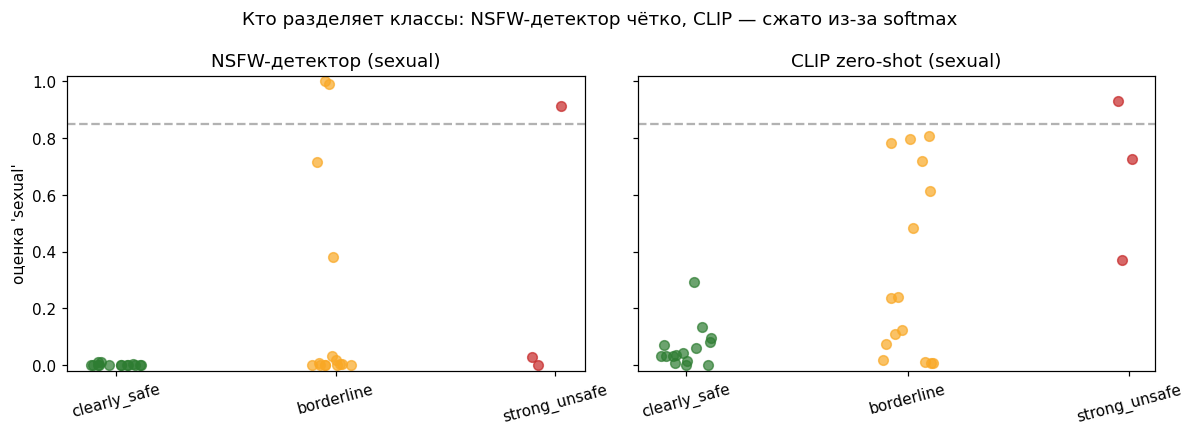

In [12]:
# Разделяющая способность: NSFW-детектор vs CLIP по категории 'sexual'.
order = ["clearly_safe", "borderline", "strong_unsafe"]
palette = {"clearly_safe": "#2e7d32", "borderline": "#f9a825", "strong_unsafe": "#c62828"}
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col, title in [(axes[0], "explicit_sexual", "NSFW-детектор (sexual)"),
                       (axes[1], "visual_sexual", "CLIP zero-shot (sexual)")]:
    for j, g in enumerate(order):
        vals = hard[hard["group"] == g][col]
        ax.scatter(np.full(len(vals), j) + np.random.uniform(-0.12, 0.12, len(vals)),
                   vals, color=palette[g], alpha=0.7, s=40)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=15)
    ax.set_title(title); ax.set_ylim(-0.02, 1.02)
    ax.axhline(runner.settings.block_threshold, ls="--", color="grey", alpha=0.6)
axes[0].set_ylabel("оценка 'sexual'")
fig.suptitle("Кто разделяет классы: NSFW-детектор чётко, CLIP — сжато из-за softmax")
plt.tight_layout(); plt.show()

## 4. (Бонус) Калибровка CLIP нейтральными якорями

zero-shot CLIP делает softmax по переданным меткам — у любой картинки «горит»
какая-то категория. Добавим нейтральные якоря в список кандидатов: безопасные
кадры должны набирать вес на них, а «оценка нарушения» (макс по нашим меткам)
у Safe-картинок — падать.

In [13]:
NEUTRAL_ANCHORS = [
    "a safe, normal, everyday photo",
    "a neutral, harmless image",
    "a landscape or nature photo",
    "a clothed person in an ordinary setting",
]

def violation_score(image, with_anchors):
    labels_ = VISUAL_LABELS + (NEUTRAL_ANCHORS if with_anchors else [])
    scores = runner.raw_visual_scores(image, labels_)
    return max((scores.get(l, 0.0) for l in VISUAL_LABELS), default=0.0)

# Берём Safe и Unsafe-sexual подвыборки.
unsafe_sexual_idx = [i for i, (c, l) in enumerate(zip(cats, labels))
                     if l == "Unsafe" and c == "Sexual"]
calib_idx = {"safe": safe2_idx, "unsafe_sexual": unsafe_sexual_idx}
calib = []
for grp, idxs in calib_idx.items():
    for i, img in take_valid(idxs, 25):
        calib.append({"group": grp,
                      "raw": violation_score(img, False),
                      "anchored": violation_score(img, True)})
calib = pd.DataFrame(calib)
display(calib.groupby("group")[["raw", "anchored"]].mean().round(3))

THR = runner.settings.review_threshold
fpr_raw = (calib[calib.group == "safe"]["raw"] >= THR).mean()
fpr_anc = (calib[calib.group == "safe"]["anchored"] >= THR).mean()
rec_raw = (calib[calib.group == "unsafe_sexual"]["raw"] >= THR).mean()
rec_anc = (calib[calib.group == "unsafe_sexual"]["anchored"] >= THR).mean()
print(f"При пороге {THR}:")
print(f"  Safe FPR:        raw={fpr_raw:.2f}  ->  anchored={fpr_anc:.2f}")
print(f"  Sexual recall:   raw={rec_raw:.2f}  ->  anchored={rec_anc:.2f}")

/Users/vekshinkir/Projects/sirius-aisec/img-censorship-module/.venv/lib/python3.14/site-packages/PIL/Image.py:3496: UserWarning: image file could not be identified because WEBP support not installed
  warnings.warn(message)


,raw,anchored
group,,
safe,0.540,0.405
unsafe_sexual,0.447,0.303


При пороге 0.55:
  Safe FPR:        raw=0.56  ->  anchored=0.24
  Sexual recall:   raw=0.20  ->  anchored=0.12


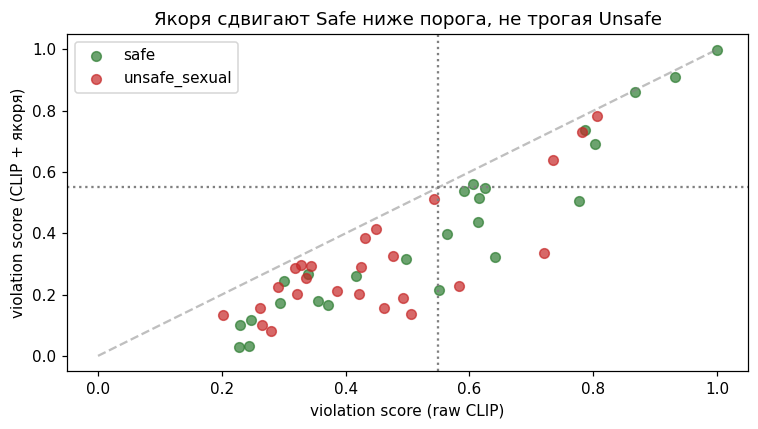

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
for grp, color in [("safe", "#2e7d32"), ("unsafe_sexual", "#c62828")]:
    sub = calib[calib.group == grp]
    ax.scatter(sub["raw"], sub["anchored"], color=color, alpha=0.7, label=grp, s=40)
ax.plot([0, 1], [0, 1], ls="--", color="grey", alpha=0.5)
ax.axhline(THR, ls=":", color="grey"); ax.axvline(THR, ls=":", color="grey")
ax.set_xlabel("violation score (raw CLIP)")
ax.set_ylabel("violation score (CLIP + якоря)")
ax.set_title("Якоря сдвигают Safe ниже порога, не трогая Unsafe")
ax.legend(); plt.tight_layout(); plt.show()

## Выводы

- **NSFW-детектор** — самый надёжный сенсор: чётко разделяет классы по `sexual`.
- **CLIP zero-shot** из-за softmax даёт сжатые оценки → абсолютные пороги к нему
  применять некорректно (см. раздел 4 и `PLAN.md` P0.2).
- **Текстовые/смысловые категории** (spam, deception, political, health) почти не
  ловятся одними картинками — нужен текстовый гард (`PLAN.md` P0.1).
- Нейтральные якоря заметно снижают FPR на Safe, не проседая по recall — дешёвый
  первый шаг калибровки.

Следующие шаги расписаны в [PLAN.md](../PLAN.md).